In [9]:
import re
import pandas as pd
import glob
import os

# Función que permite procesar el log asociado a un experimento y devuelve 3 elementos: 
# el resumen del rendimiento y tiempos en cada dataset, las estadisticas globales y el accuracy por clase.
def procesar_log_detallado(ruta_archivo):

    # Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    # Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    # Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        # 1. Obtenemos el nombre del dataset"""  """
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        # 2. Extraemos el OA y AA finales obtenidos sobre el dataset
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        # NUEVO: 2.5 Extraemos las medidas de tiempo
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        # Si se han encontrado el OA y el AA se añaden al resumen de resultados
        if oa_match and aa_match:
            datos_dataset = {
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2))
            }
            
            # Añadimos los tiempos si los encuentra (por si algún log antiguo no los tiene, evitamos errores)
            if tiempo_total_match:
                datos_dataset["Tiempo Total (s)"] = float(tiempo_total_match.group(1))
            else:
                datos_dataset["Tiempo Total (s)"] = None
                
            if tiempo_epoca_match:
                datos_dataset["Tiempo por Época (s)"] = float(tiempo_epoca_match.group(1))
            else:
                datos_dataset["Tiempo por Época (s)"] = None

            resumen_data.append(datos_dataset)
            
        # 3. Extraemos el accuracy obtenido para cada clase
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            # Obtenemos los resultados para cada clase (ignorando la desviación típica de la clase, como en tu código original)
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            # Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    # Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    # Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    # Transformamos la tabla de clases a formato ancho
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    # Calculamos las estadísticas globales
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(),df_resumen["Tiempo Total (s)"].mean(),df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(),df_resumen["Tiempo por Época (s)"].std()]
    }
    
    # Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [10]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo)
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")

            nombre_prueba = os.path.basename(archivo).replace(".log", "").replace("resultados_", "")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]

                t_total_medio = df_res["Tiempo Total (s)"].mean() if "Tiempo Total (s)" in df_res.columns else None
                t_epoca_medio = df_res["Tiempo por Época (s)"].mean() if "Tiempo por Época (s)" in df_res.columns else None
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std,
                    "Tiempo Total Medio (s)": t_total_medio,
                    "Tiempo Época Medio (s)": t_epoca_medio
                })
            else:
                print(df_res)

        if datos_comparacion:
            datos_ordenados = sorted(
                datos_comparacion, 
                key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
                reverse=True
            )
            
            
            
            # Definimos anchos fijos para reutilizar y evitar errores de cálculo
            w_rank = 8
            w_metodo = 40  # Aumentado para dar aire a nombres largos
            w_oa = 22
            w_aa = 22

            print(f"\n\n{'='*30} RESUMEN RESULTADOS {'='*30}")

            # Encabezado
            header = f"{'Ranking':<{w_rank}} | {'Método':<{w_metodo}} | {'OA Global (%) ± Std':<{w_oa}} | {'AA Global (%) ± Std':<{w_aa}}"
            print(header)
            print("-" * len(header))

            # Filas
            for i, dato in enumerate(datos_ordenados, start=1):
                oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
                aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
                
                # Usamos las mismas variables de ancho (w_rank, w_metodo, etc.)
                print(f"#{i:<{w_rank-1}} | {dato['Prueba']:<{w_metodo}} | {oa_str:<{w_oa}} | {aa_str:<{w_aa}}")

            print("=" * len(header))
    
        return datos_comparacion

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        df_comparacion = pd.DataFrame(datos_comparacion)

        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        
        # Comprobamos si los tiempos se han extraído correctamente y no son todos nulos
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        
        num_graficas = 3 if tiene_tiempos else 2
        fig, axes = plt.subplots(num_graficas, 1, figsize=(12, 7 * num_graficas), sharex=False)
        
        # Asignamos los ejes
        ax1 = axes[0]
        ax2 = axes[1]

        # --- 1. Gráfica de Precisión ---
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'], alpha=0.8
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Precisión (%)')
        ax1.set_ylim(80, 100)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Forzar la leyenda en un sitio fijo
        ax1.legend(["OA Global", "AA Global"], loc='upper right')

        # --- 2. Gráfica de Desviación ---
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', ax=ax2, color=['#2ca02c', '#d62728'], alpha=0.8
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Variación (%)')
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        
        ax2.legend(["OA Std", "AA Std"], loc='upper right')

        # --- 3. Gráfica de Tiempos (SOLO TIEMPO POR ÉPOCA) ---
        if tiene_tiempos:
            ax3 = axes[2]
            
            df_comparacion.set_index('Prueba')[['Tiempo Época Medio (s)']].plot(
                kind='bar', 
                ax=ax3, 
                color=['#8c564b'], # Color marrón para diferenciarlo de los anteriores
                alpha=0.8
            )
            
            ax3.set_title('Coste Computacional (Tiempo Medio por Época)', fontsize=14, fontweight='bold')
            ax3.set_ylabel('Tiempo (segundos)')

            ax3.set_ylim(bottom=0.8)

            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            ax3.legend(["Tiempo Medio por Época"], loc='upper right')

        # Ajustes finales
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Experimentos')
        
        plt.tight_layout()
        plt.show()

## Resultados

In [12]:
#Leemos los resultados asociados a las ejecuciones sin usar el oversampling
ruta_carpeta = "resultadosPruebasVIT"

datos_orig=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_VIT+CUTMIX.log ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
        oitaven   96.28        0.15   94.16        0.45            734.83                7.3483
     das_mestas   91.06        0.06   89.59        0.12           1332.15               13.3215
      eiras_dam   95.35        0.47   91.26        1.42            515.17                5.1517
  ermidas_creek   98.51        0.16   97.15        0.45            799.15                7.9915
ferreiras_river   91.97        0.10   80.86        2.11           1828.21               18.2821
     mera_river   91.25        0.04   89.36        4.93           2061.90               20.6190
           ulla   97.12        1.66   96.04        3.33             54.36                0.5436
          xesta   98.83        0.04   94.94        1.04           2067.97         

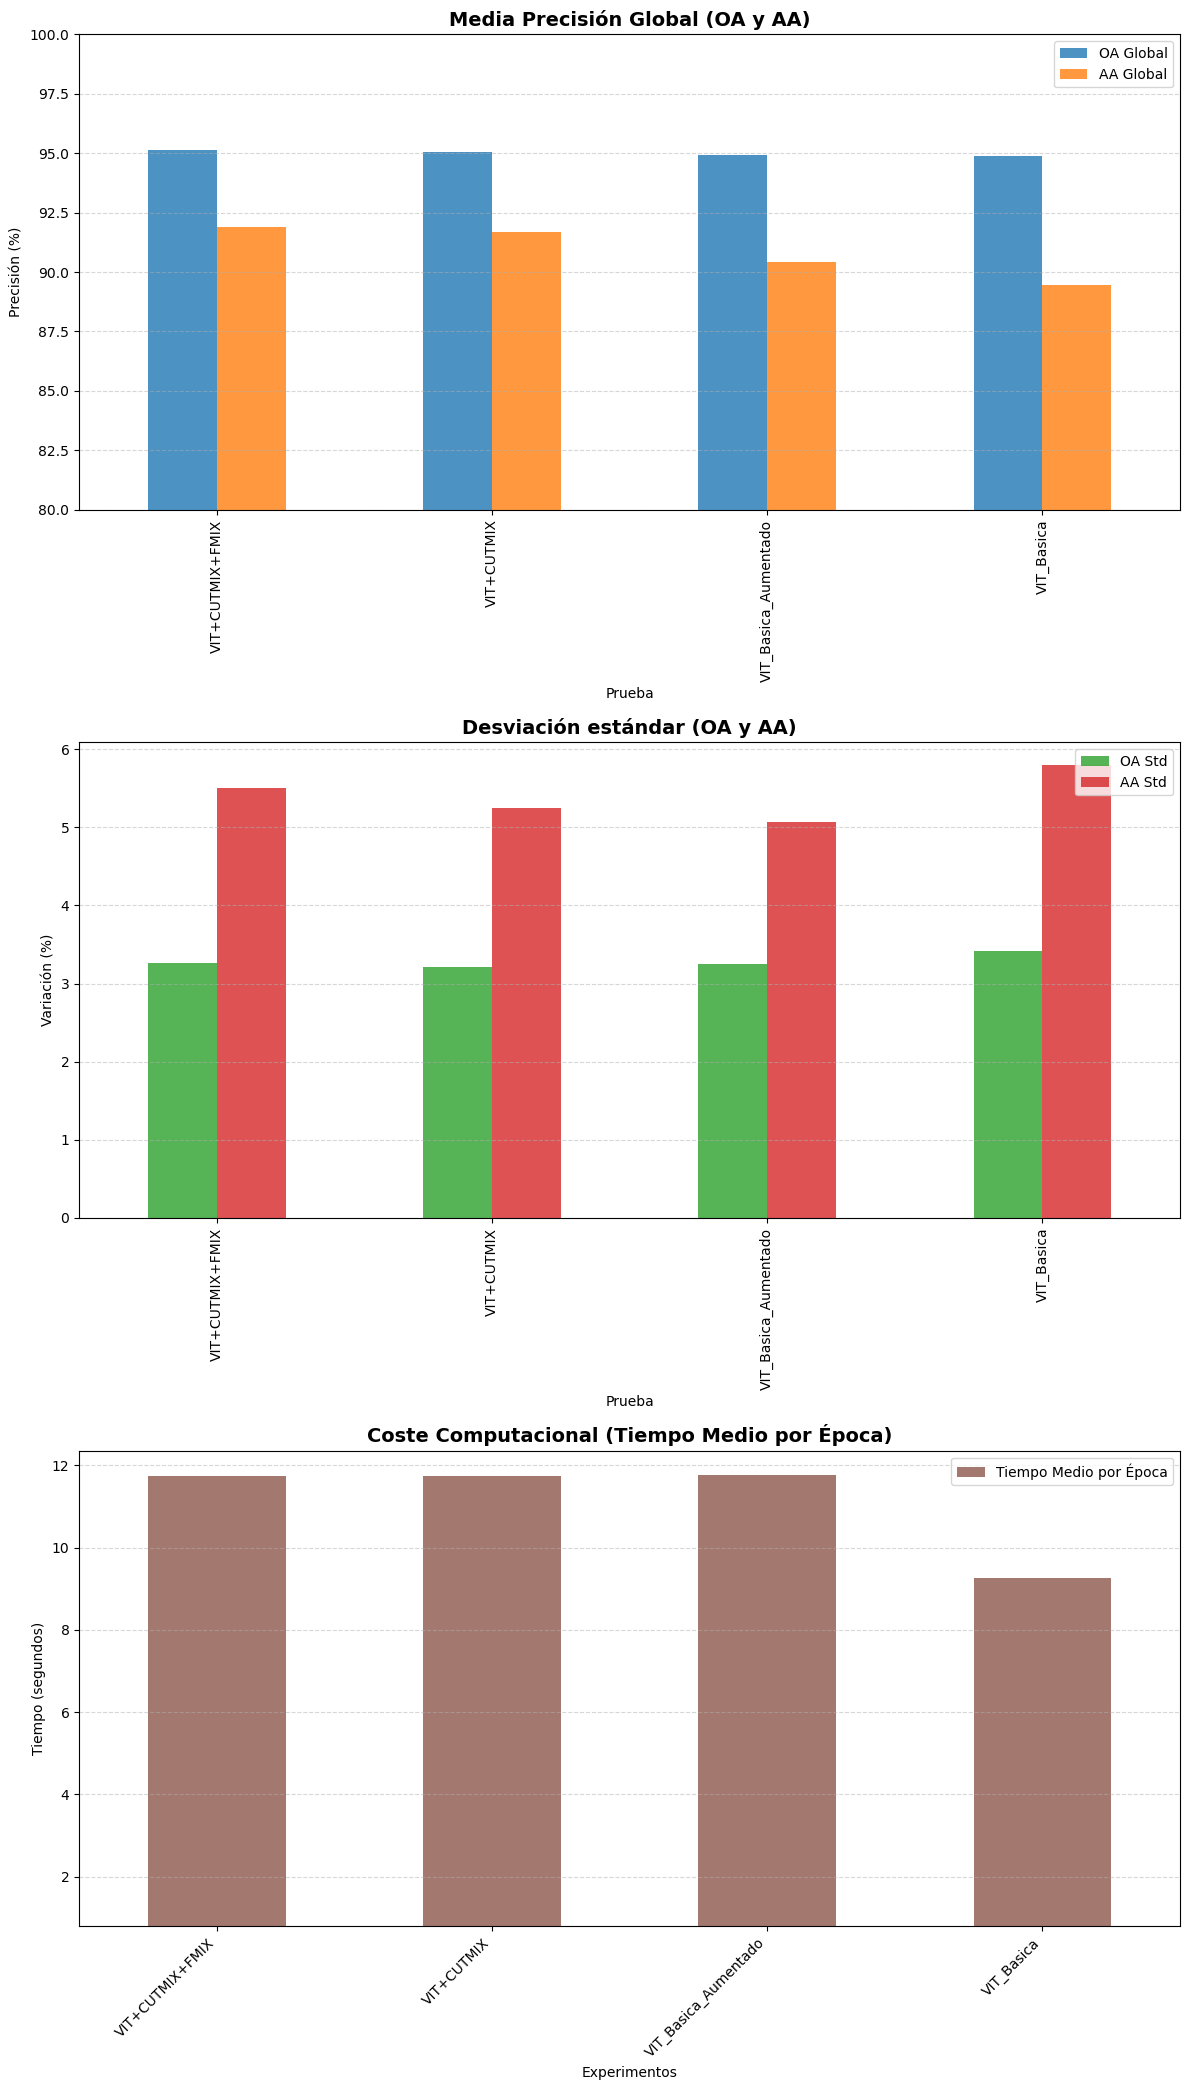

In [13]:
graficaComparacionModelos(datos_orig)

# Comportamiento de las distintas versiones por cada dataset

In [14]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import os

def graficar_clases_separado_limpio(dataset_objetivo):
    modelos_base = ["VIT+CUTMIX","VIT+CUTMIX+FMIX" ,"VIT_Basica_Aumentado", "VIT_Basica"]
    df_original = pd.DataFrame()


    # 1. RECOLECCIÓN DE DATOS
    for modelo in modelos_base:
        ruta_orig = os.path.join("resultadosPruebasVIT", f"resultados_{modelo}.log")

        
        # Procesar Originales
        if os.path.exists(ruta_orig):
            _, _, df_clases_orig = procesar_log_detallado(ruta_orig)
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                df_original[modelo] = df_clases_orig.loc[dataset_objetivo]
        


    # 2. FILTRADO: Eliminar clases que no existen en este dataset (valores NaN o 0)
    # Eliminamos filas si todos los modelos tienen NaN o 0 en esa clase
    if not df_original.empty:
        df_original = df_original.dropna(how='all') # Elimina si todo es NaN
        df_original = df_original[(df_original > 0).any(axis=1)] # Elimina si todo es 0
    

    # 3. CÁLCULO DEL YMIN DINÁMICO (Decena inferior)
    todos_valores = df_original.values.flatten()
    valores_validos = [v for v in todos_valores if v > 0 and not pd.isna(v)]
    
    ymin = (min(valores_validos) // 10) * 10 if valores_validos else 0

    # 4. GENERACIÓN DE GRÁFICAS
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 8))

    # Gráfica 1: Originales
    if not df_original.empty:
        df_original.plot(kind='bar', ax=ax1, width=0.8, colormap='tab10')
        ax1.set_title(f'Dataset: {dataset_objetivo} - ORIGINALES', fontsize=14, fontweight='bold')
        ax1.set_ylim(ymin, 100)
        ax1.set_ylabel('Accuracy (%)')
        ax1.grid(axis='y', linestyle='--', alpha=0.4)
        ax1.legend(title="Modelos", loc='upper left', bbox_to_anchor=(1, 1))


    plt.tight_layout()
    plt.show()

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

Generando gráficas para: das_mestas...


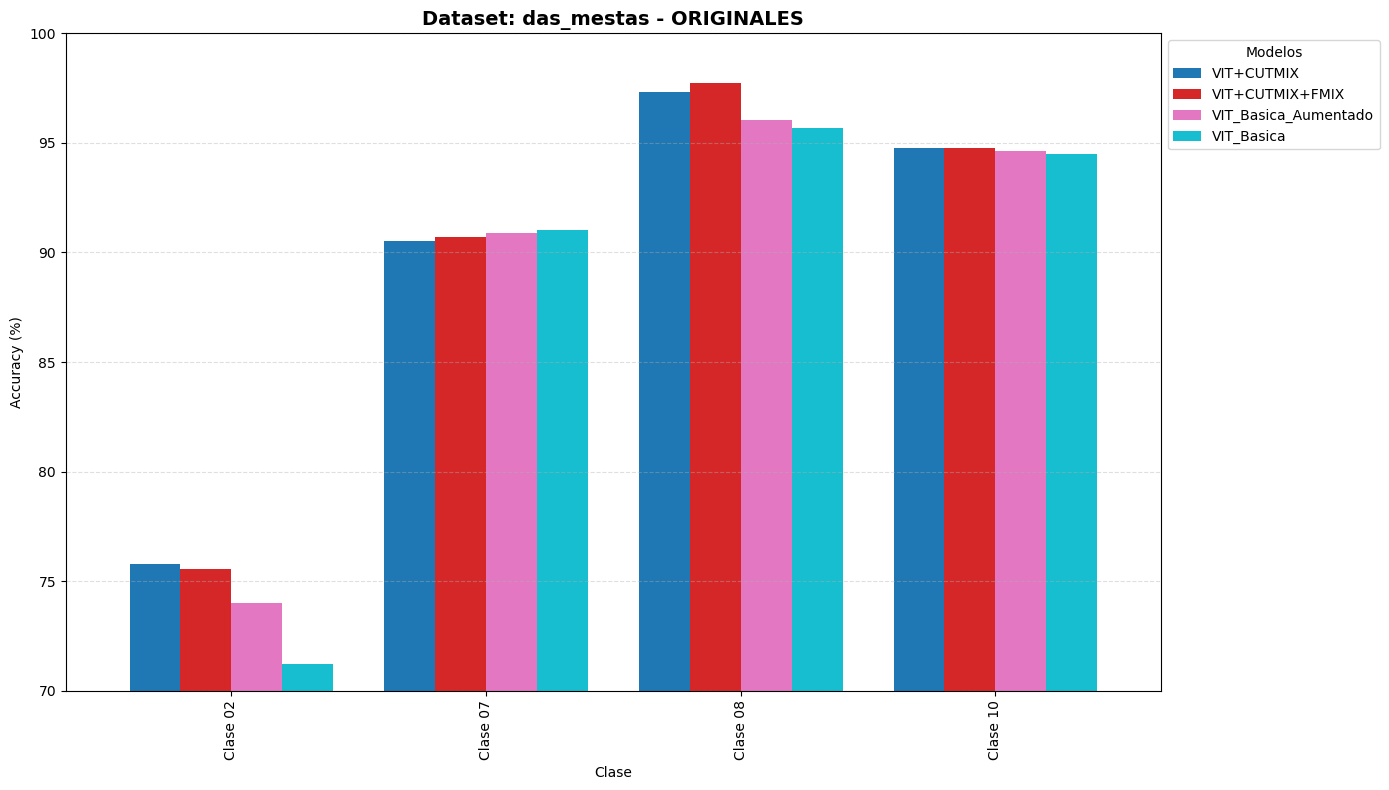


Generando gráficas para: eiras_dam...


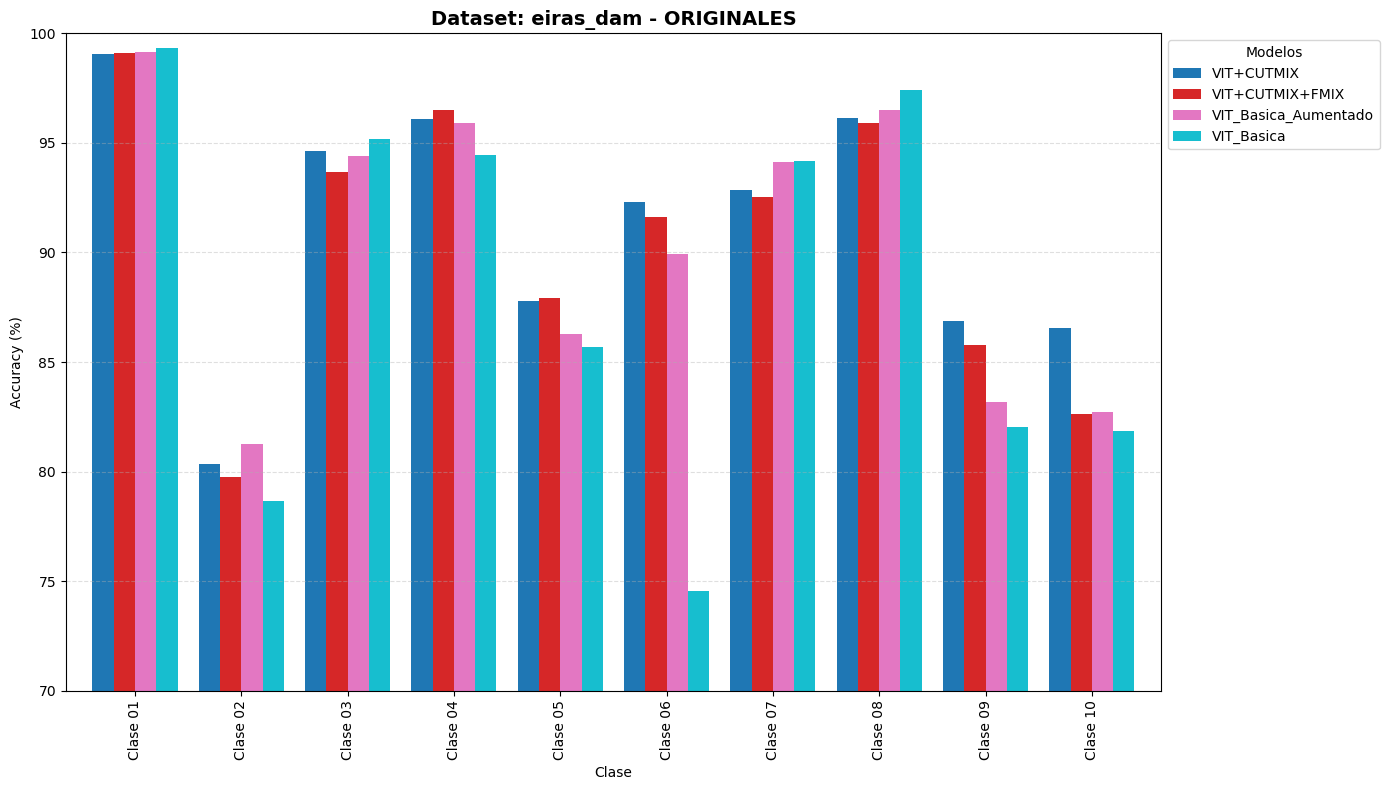


Generando gráficas para: ermidas_creek...


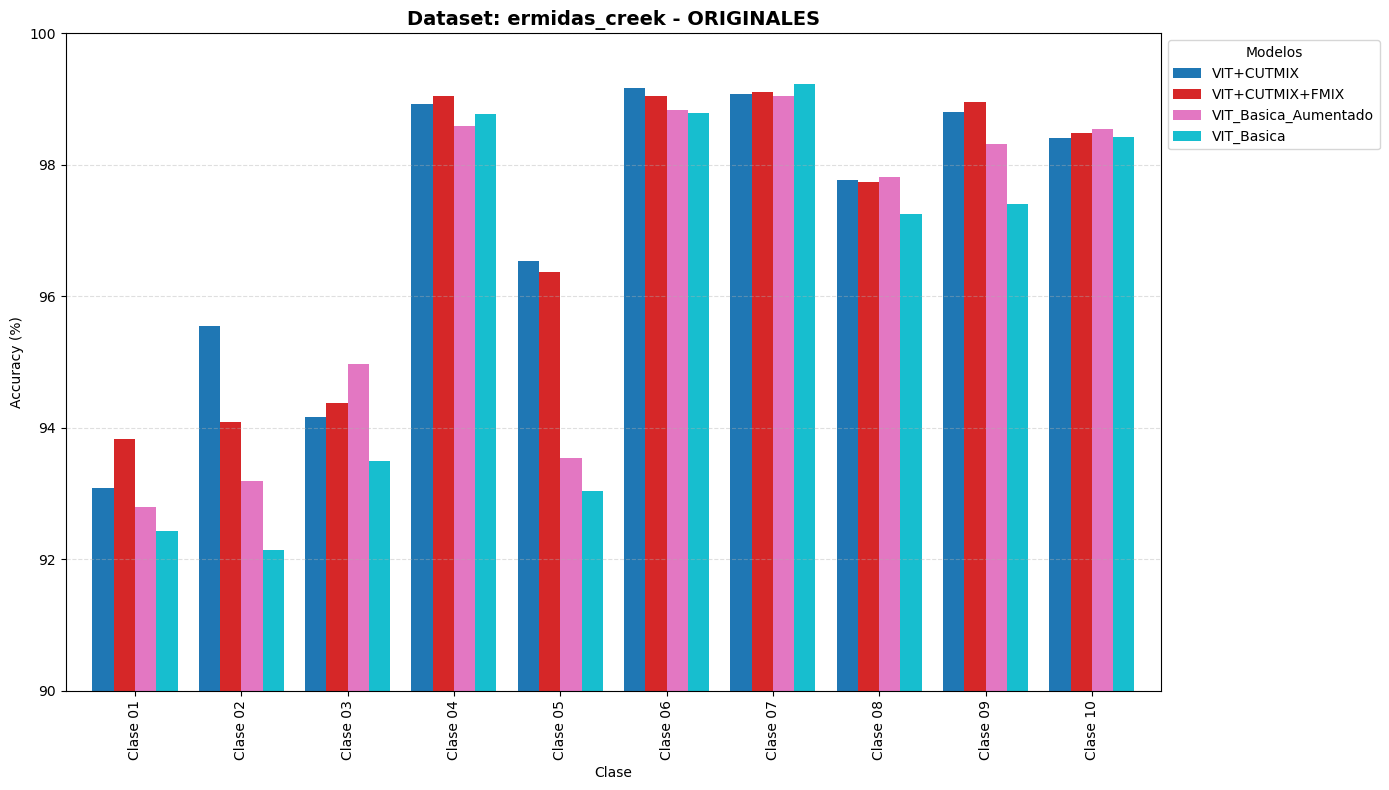


Generando gráficas para: ferreiras_river...


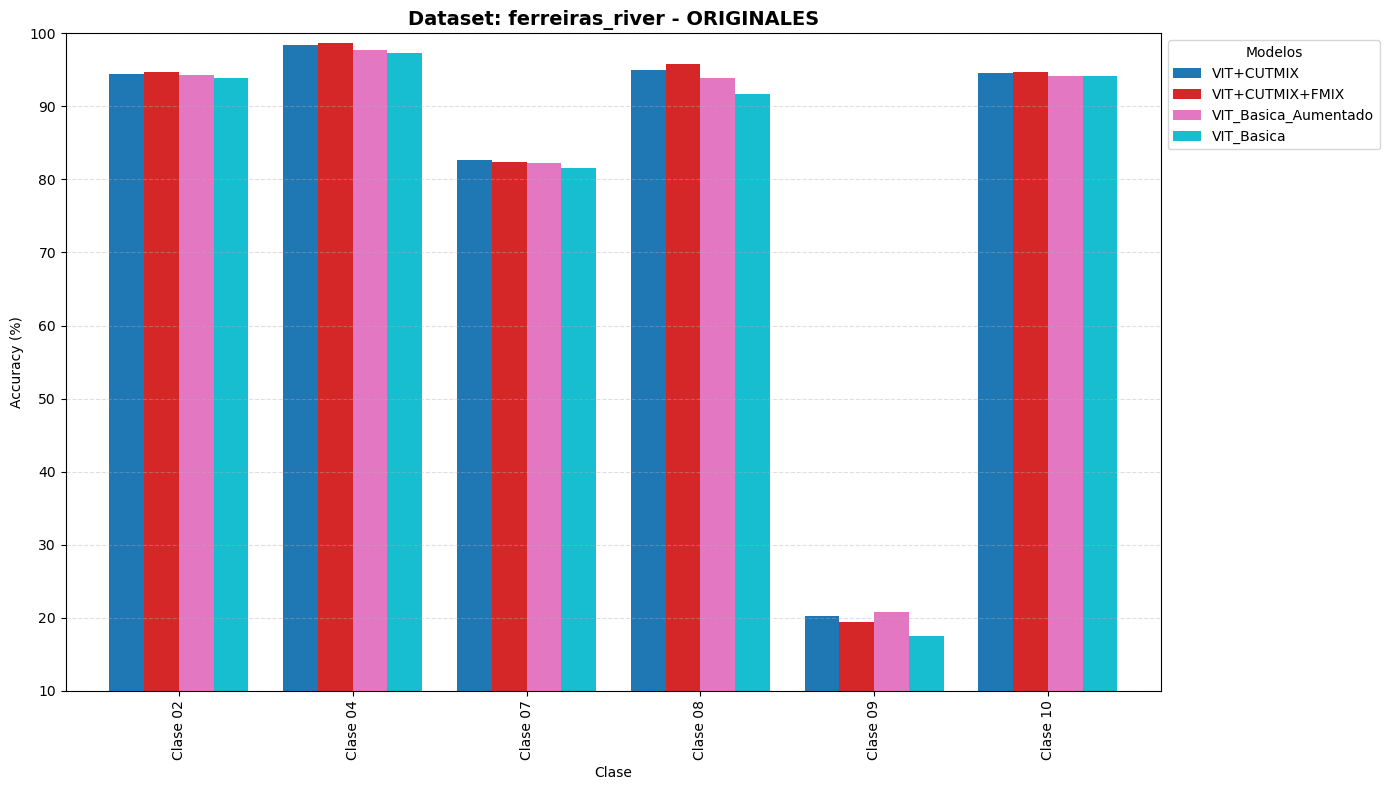


Generando gráficas para: mera_river...


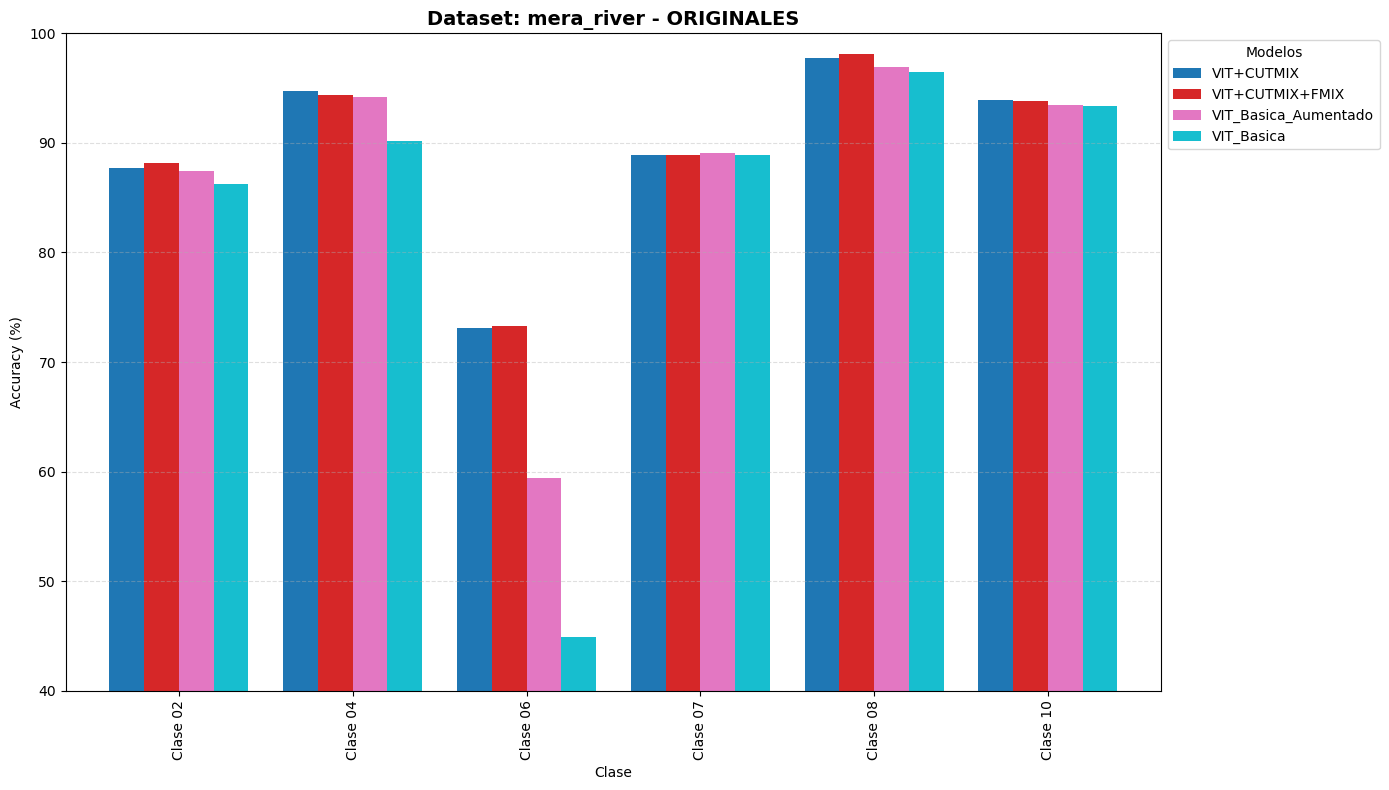


Generando gráficas para: oitaven...


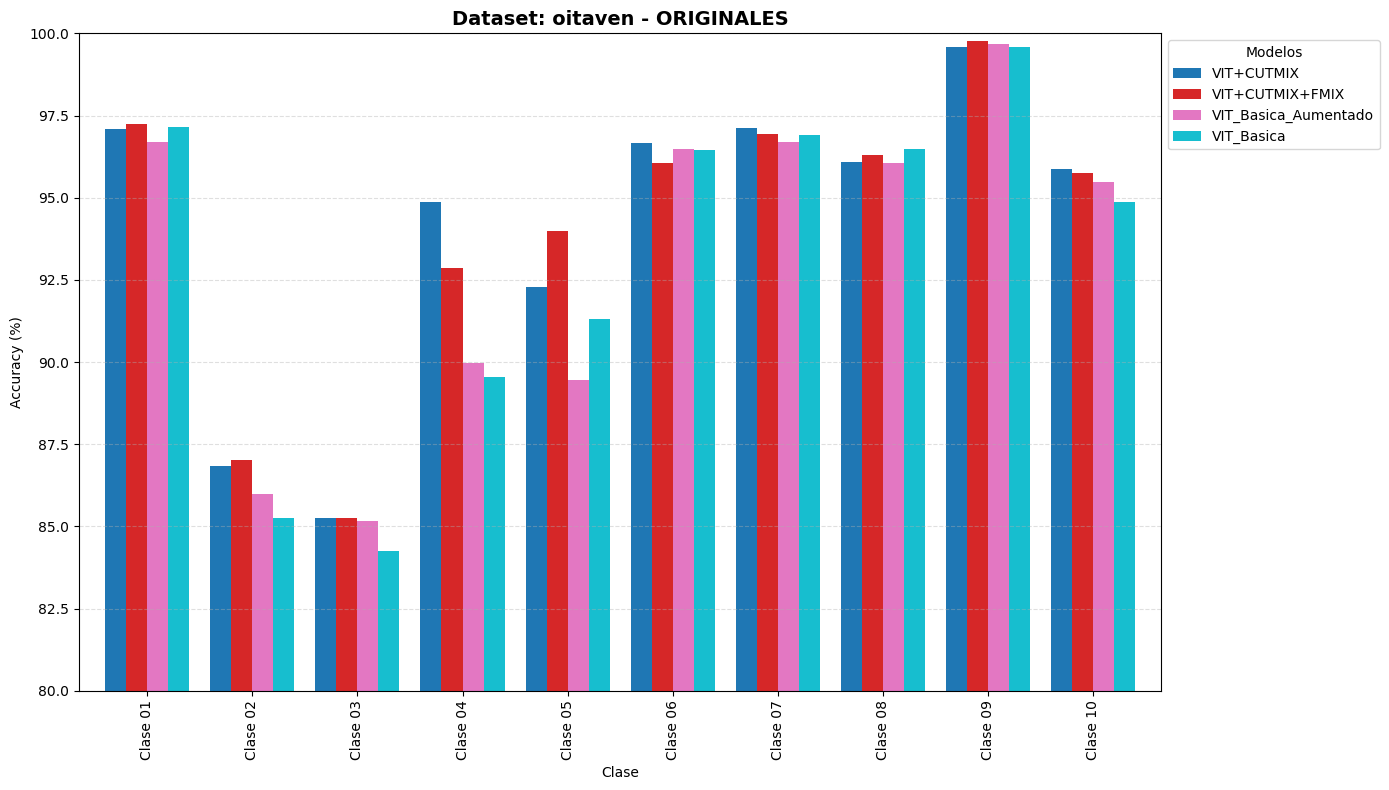


Generando gráficas para: ulla...


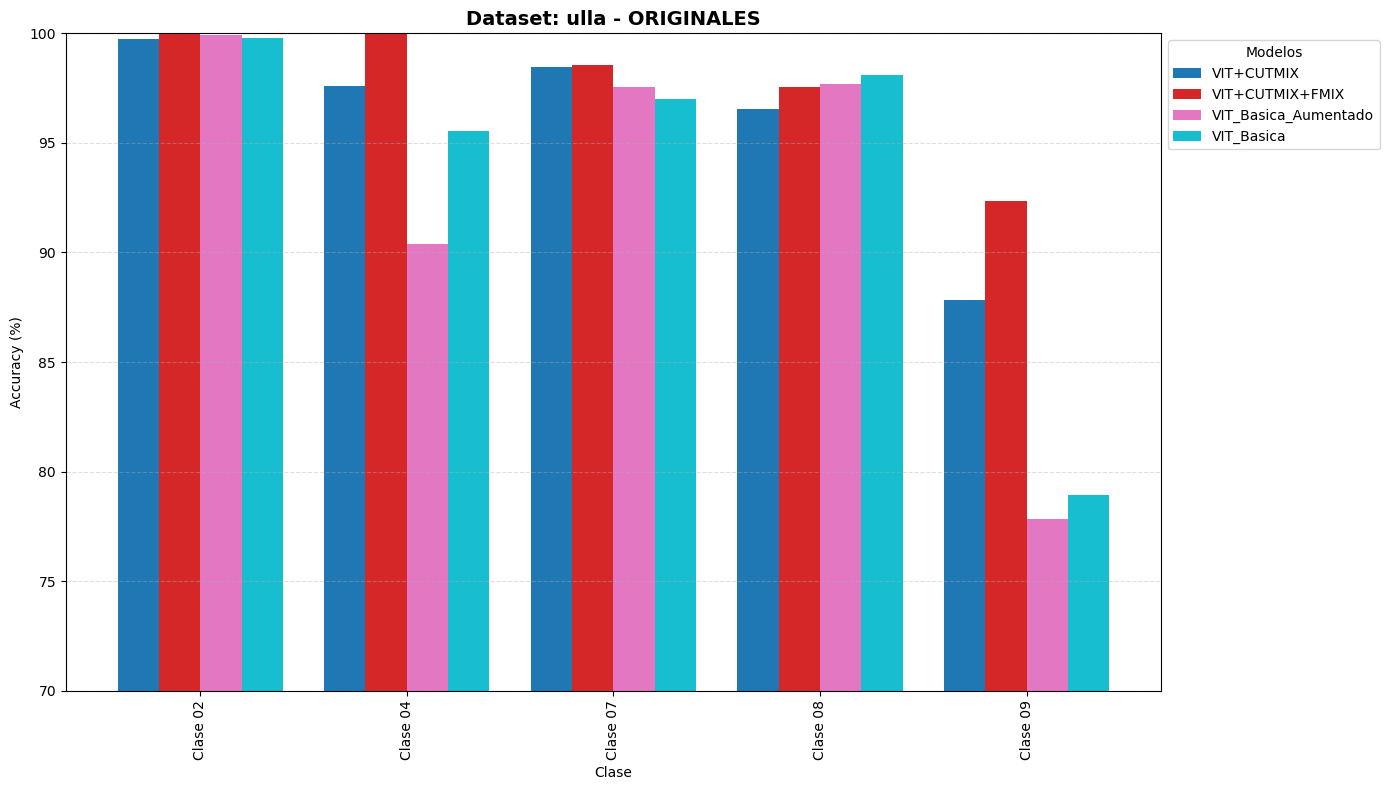


Generando gráficas para: xesta...


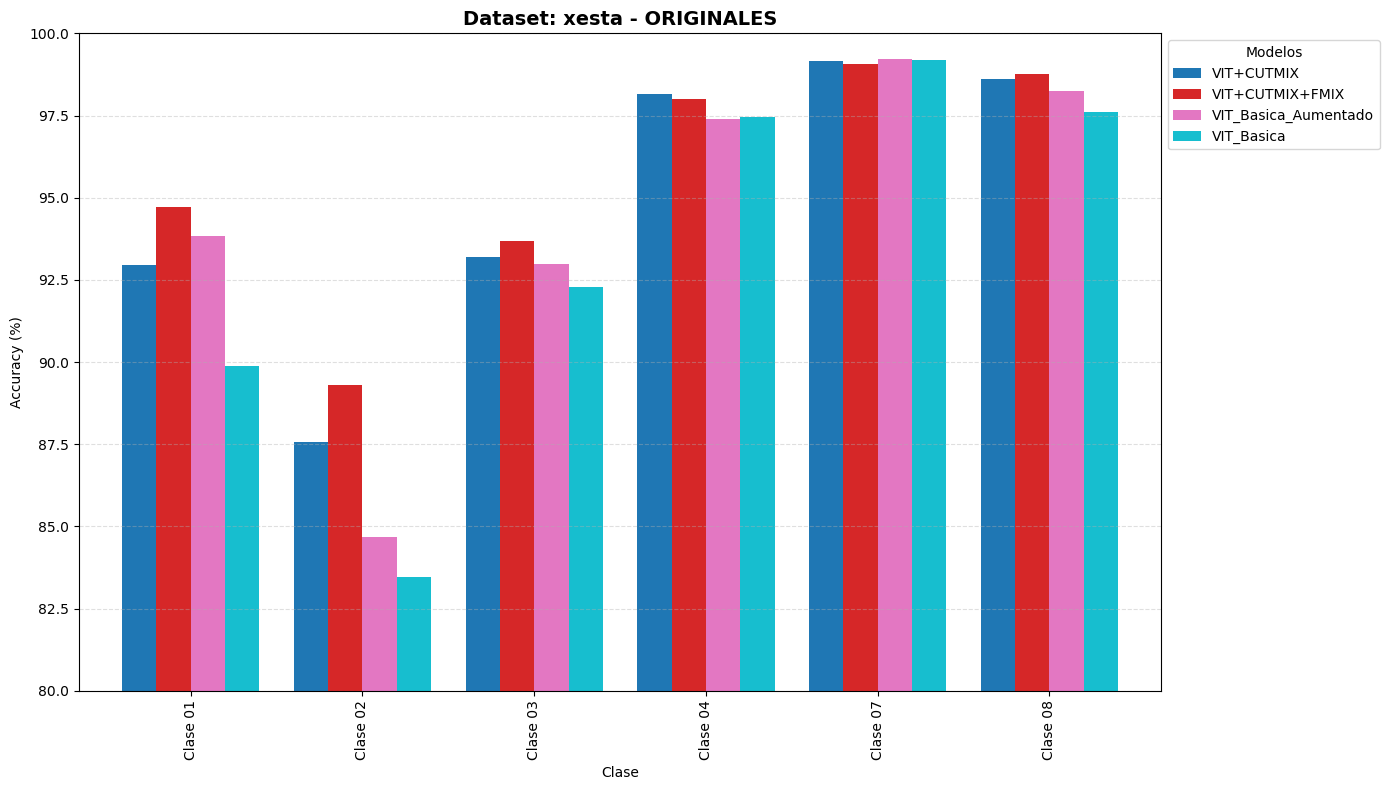

In [15]:
# 1. Obtener la lista de todos los datasets disponibles en tus logs
def obtener_lista_datasets():
    # Usamos cualquier archivo de la carpeta original para extraer los nombres
    archivos = glob.glob(os.path.join("resultadosPruebasVIT", "*.log"))
    if not archivos:
        return []
    
    # Procesamos el primero que encontremos para sacar los nombres de los indices
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# 2. Ejecutar la gráfica para cada dataset encontrado
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        print(f"\nGenerando gráficas para: {ds}...")
        graficar_clases_separado_limpio(ds)